In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. Load data
df = pd.read_csv('mail_data.csv')

# 2. Identify columns (Adjust 'Category' and 'Message' if your print(df.columns) showed different names)
X = df['Message']   # The actual email text
y = df['Category']  # 'spam' or 'ham'

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Vectorize text (Turning words into a matrix of numbers)
# No loops: fit_transform handles the entire column in parallel
tfidf = TfidfVectorizer(stop_words='english')
X_train_transformed = tfidf.fit_transform(X_train)
X_test_transformed = tfidf.transform(X_test)

# 5. Train Model
model = MultinomialNB()
model.fit(X_train_transformed, y_train)

# 6. Accuracy
accuracy = model.score(X_test_transformed, y_test)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 97.67%


In [15]:
# Get the class labels (Ham or Spam)
y_pred = model.predict(X_test_transformed)

# Create a small table to compare actual vs predicted
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results_df.head(10))

  Actual Predicted
0    ham       ham
1    ham       ham
2    ham       ham
3    ham       ham
4    ham       ham
5    ham       ham
6    ham       ham
7    ham       ham
8    ham       ham
9    ham       ham


In [11]:
# 1. Write a suspicious message
my_mail = ["URGENT: Your account has been compromised. Click here to reset your password and win $500!"]

# 2. Transform it (vectorize)
my_mail_transformed = tfidf.transform(my_mail)

# 3. Predict!
prediction = model.predict(my_mail_transformed)

print(f"Result: {prediction[0]}")

Result: spam


In [13]:
# 1. Write a normal (Ham) message
my_mail = ["Hey, are we still meeting for coffee at 3 PM today? Let me know if you're busy."]

# 2. Transform it using the same TF-IDF vectorizer
# No loops needed: it treats the list as a batch of 1
my_mail_transformed = tfidf.transform(my_mail)

# 3. Predict!
prediction = model.predict(my_mail_transformed)

# 4. Show the output
print(f"Result: {prediction[0]}")

Result: ham


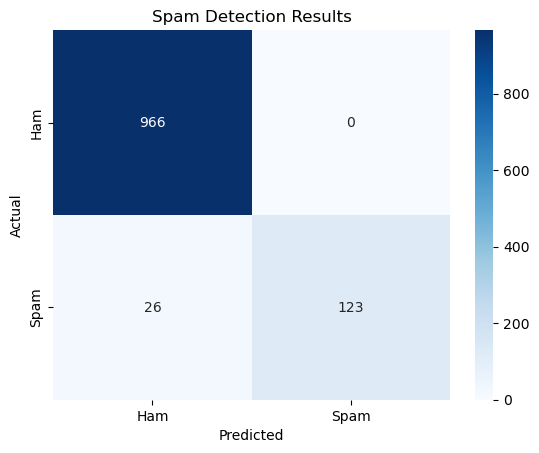

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Spam Detection Results')
plt.show()